{'Sequence ID': 'NM_002055.5', 'Sequence length': 5501, 'gc': 57.116887838574804, 'sequence': Seq('AGAGCCAGAGCAGGATGGAGAGGAGACGCATCACCTCCGCTGCTCGCCGCTCCT...TTA')}
{'Sequence ID': 'NM_006272.2', 'Sequence length': 1135, 'gc': 53.03964757709251, 'sequence': Seq('GGGCAGAGGGAATAAGAGGCTGCCTCTGCCCACCAGTCCTGCCGCCCAGGACCC...AAG')}
{'Sequence ID': 'NM_000484.4', 'Sequence length': 3583, 'gc': 48.50683784538097, 'sequence': Seq('GTCAGTTTCCTCGGCAGCGGTAGGCGAGAGCACGCGGAGGAGCGTGCGCGGGGG...GCA')}
{'Sequence ID': 'NM_001377265.1', 'Sequence length': 6815, 'gc': 57.09464416727806, 'sequence': Seq('GCAGTCACCGCCACCCACCAGCTCCGGCACCAACAGCAGCGCCGCTGCCACCGC...AAA')}
{'Sequence ID': 'KR710721.1', 'Sequence length': 873, 'gc': 47.88087056128293, 'sequence': Seq('GTTCGTTGCAACAAATTGATGAGCAATGCTTTTTTATAATGCCAACTTTGTACA...AAC')}


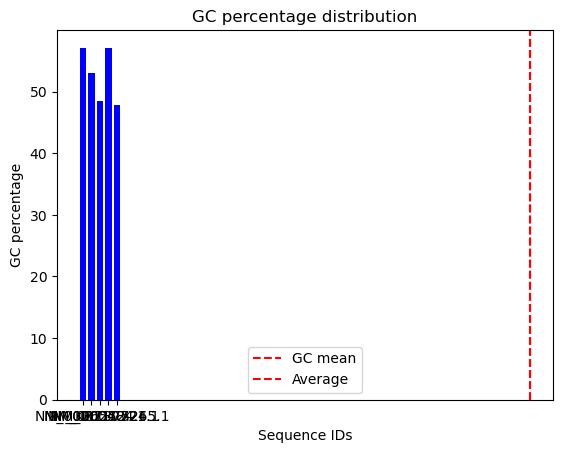

array([57.11688784, 53.03964758, 48.50683785, 57.09464417, 47.88087056])

In [1]:
from Bio import Entrez, SeqIO
import matplotlib.pyplot as plt
import time 
import numpy as np
Entrez.email = "diegoblancob2011@gmail.com"
genes_list = ["NM_002055.5", "NM_006272.2","NM_000484.4", "NM_001377265", "KR710721.1"]


def fetch_sequence(accession_id):
    try:
        handle = Entrez.efetch(db="nucleotide", id=accession_id, rettype="fasta", retmode="text")
        record = SeqIO.read(handle, "fasta")
        handle.close()
        genes={
        "Sequence ID": record.id,
        "Sequence length": len(record.seq),
        "gc": (record.seq.count('G') + record.seq.count('C')) / len(record.seq) * 100,
        "sequence": record.seq
        }
        return genes
    except Exception as e:
        print(f"Error fetching sequence for {accession_id}: {e}")
        return None
   
    
def genes_loop():
    gc_list = []
    genes = [] 
    mean = 0
    average = 0
    for gene in genes_list:
        time.sleep(1)
        result = fetch_sequence(gene)
        if result is not None:
            genes.append(result)  
        print(result)
    for x in genes:
        gc_list.append(x["gc"])
    gc_array = np.array(gc_list)
    nombres = [x["Sequence ID"] for x in genes]
    mean = np.mean(gc_array)
    average = np.average(gc_array)
    plt.bar(nombres, gc_array, color='blue')
    plt.title("GC percentage distribution")
    plt.xlabel("Sequence IDs")
    plt.ylabel("GC percentage")
    plt.axvline(mean, color='red', linestyle='--', label="GC mean")
    plt.axvline(average, color='red', linestyle='--', label="Average")
    plt.legend()
    plt.show()
    return gc_array




genes_loop()



    

